In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
AdaBoostClassifier,
GradientBoostingClassifier,VotingClassifier,
StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
breast_cancer = load_breast_cancer(as_frame=True)

# Create a DataFrame
df = breast_cancer.frame

# Display the first few rows and column names
display(df.head())
print(df.columns)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [12]:
# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


Decision Tree Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



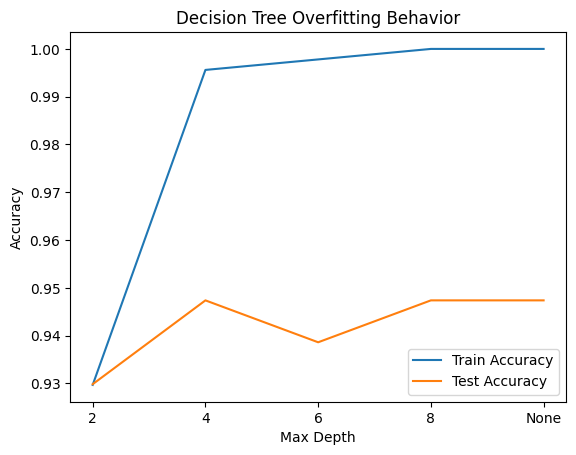

In [13]:
# ============================================================
# 🌳 3. Decision Tree Classifier
# ============================================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Experiment: Vary max_depth to Observe Overfitting
depths = [2, 4, 6, 8, None]
acc_train, acc_test = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc_train.append(model.score(X_train, y_train))
    acc_test.append(model.score(X_test, y_test))

plt.plot([str(d) for d in depths], acc_train, label='Train Accuracy')
plt.plot([str(d) for d in depths], acc_test, label='Test Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Behavior")
plt.legend()
plt.show()

Random Forest Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



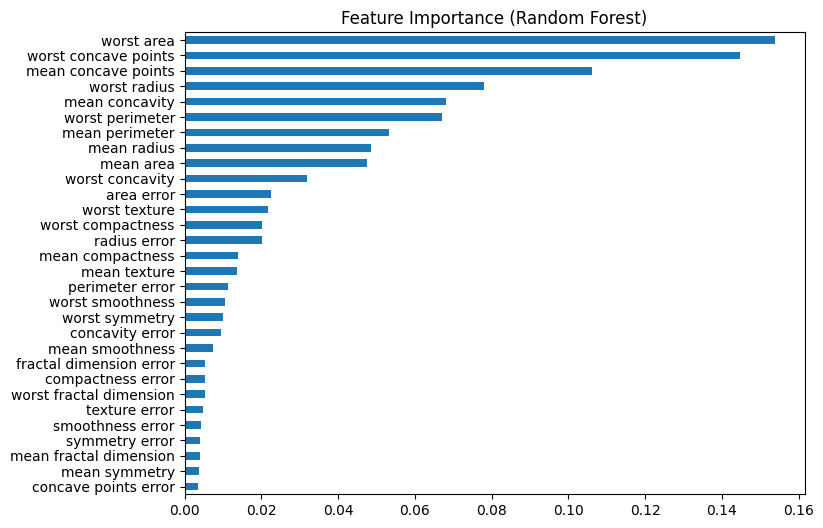

In [14]:
# ============================================================
# 🌲 4. Random Forest Classifier (Bagging Example)
# ============================================================

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importance Visualization
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [15]:
# ============================================================
# ⚡ 5. Boosting Methods
# ============================================================

# (a) AdaBoost Classifier
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

# (b) Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

AdaBoost Accuracy: 0.9736842105263158
Gradient Boosting Accuracy: 0.956140350877193


In [16]:
# ============================================================
# 🗳️ 6. Voting Classifier (Hard & Soft Voting)
# ============================================================

lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Hard Voting
voting_hard = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('rf', rf)],
    voting='hard'
)
voting_hard.fit(X_train, y_train)
print("Hard Voting Accuracy:", accuracy_score(y_test, voting_hard.predict(X_test)))

# Soft Voting
voting_soft = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('rf', rf)],
    voting='soft'
)
voting_soft.fit(X_train, y_train)
print("Soft Voting Accuracy:", accuracy_score(y_test, voting_soft.predict(X_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Hard Voting Accuracy: 0.9649122807017544


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Soft Voting Accuracy: 0.9649122807017544


In [17]:
# ============================================================
# 🧱 7. Stacking Classifier (Meta-Learning)
# ============================================================

base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('ada', AdaBoostClassifier(n_estimators=50, random_state=42))
]

meta_model = LogisticRegression()

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stack))

Stacking Classifier Accuracy: 0.9736842105263158


/tmp/ipython-input-2664730008.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results.sort_values(by='Accuracy', ascending=True), palette='viridis')


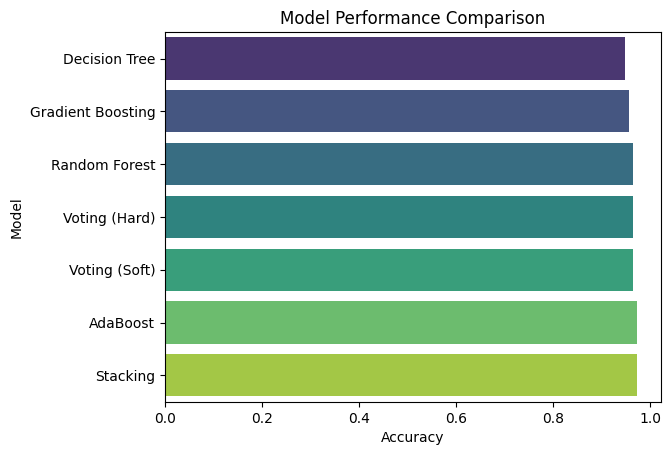

               Model  Accuracy
0      Decision Tree  0.947368
1      Random Forest  0.964912
2           AdaBoost  0.973684
3  Gradient Boosting  0.956140
4      Voting (Hard)  0.964912
5      Voting (Soft)  0.964912
6           Stacking  0.973684


In [18]:
# ============================================================
# 📊 8. Model Comparison Summary
# ============================================================

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting',
              'Voting (Hard)', 'Voting (Soft)', 'Stacking'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, voting_hard.predict(X_test)),
        accuracy_score(y_test, voting_soft.predict(X_test)),
        accuracy_score(y_test, y_pred_stack)
    ]
})

sns.barplot(x='Accuracy', y='Model', data=results.sort_values(by='Accuracy', ascending=True), palette='viridis')
plt.title("Model Performance Comparison")
plt.show()

print(results)